<a href="https://colab.research.google.com/github/JiyaBhalla-10/CardioPredict/blob/main/Copy_of_heart_disease_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Set Plot Style
sns.set_style("whitegrid")

In [ ]:
# LOAD DATASET

df = pd.read_csv("/content/Cardiovascular_Disease_Dataset.csv")

In [ ]:
# BASIC DATA ANALYSIS

print("Shape of Dataset:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(1000, 14)

First 5 Rows:
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1      5.0   
3                  1                1           153              0      3.2   
4                  0                2           136              0      5.3   

   slope  noofmajorvessels  target  
0      3                 3       1 

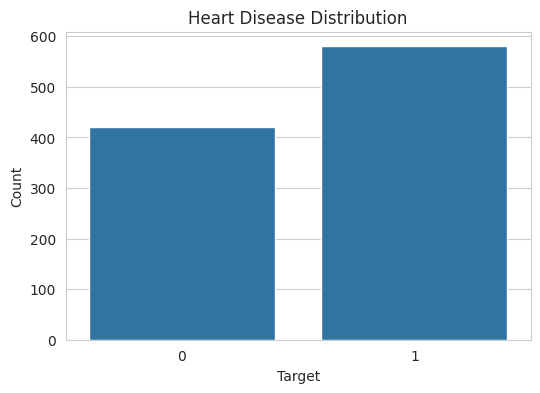

In [ ]:
# TARGET VARIABLE DISTRIBUTION

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title('Heart Disease Distribution')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

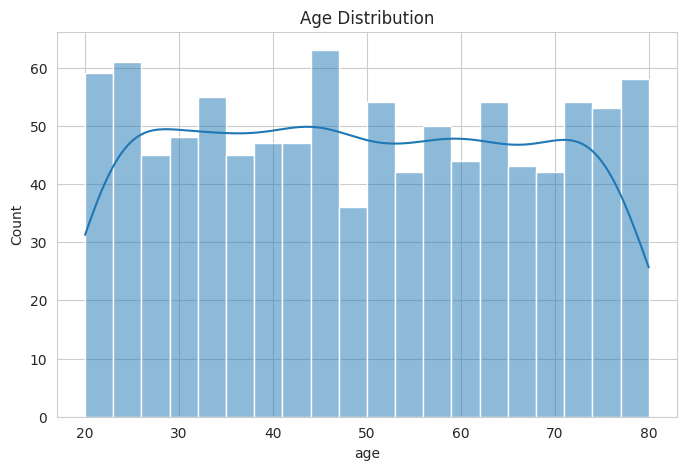

In [ ]:
# AGE DISTRIBUTION

plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

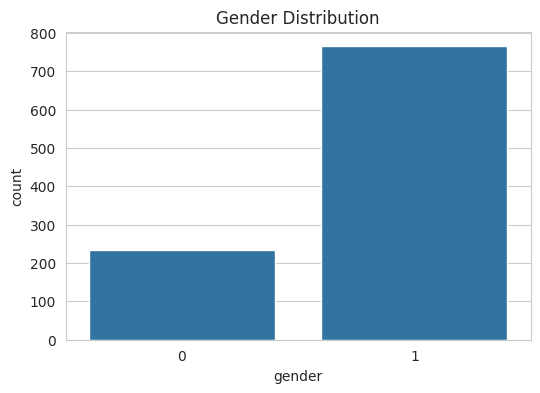

In [ ]:
# GENDER DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

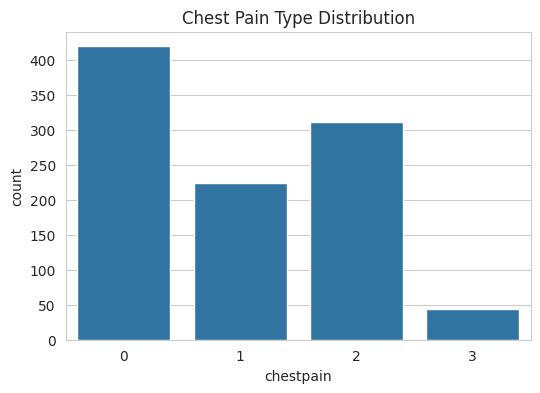

In [ ]:
# CHEST PAIN DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(x='chestpain', data=df)
plt.title("Chest Pain Type Distribution")
plt.show()

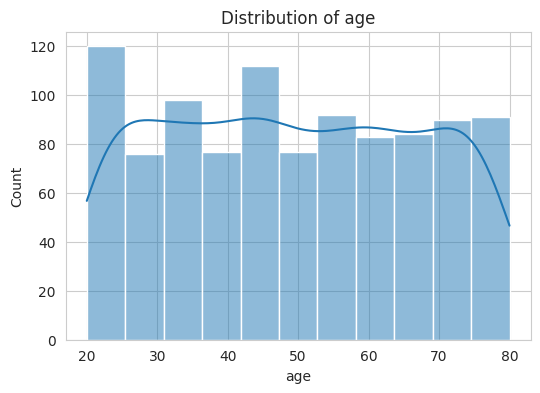

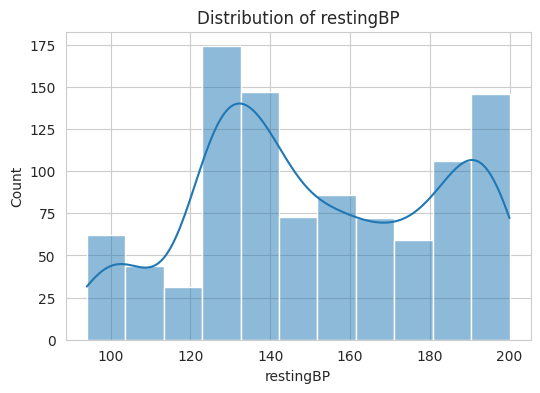

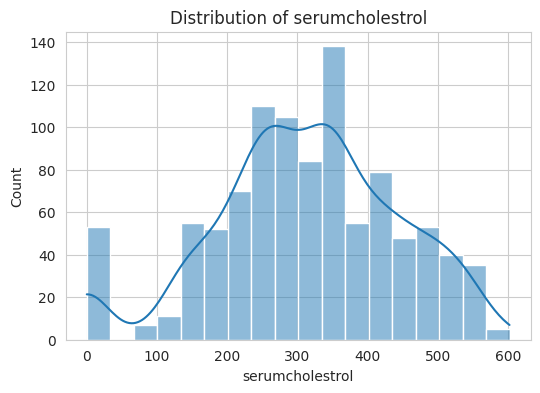

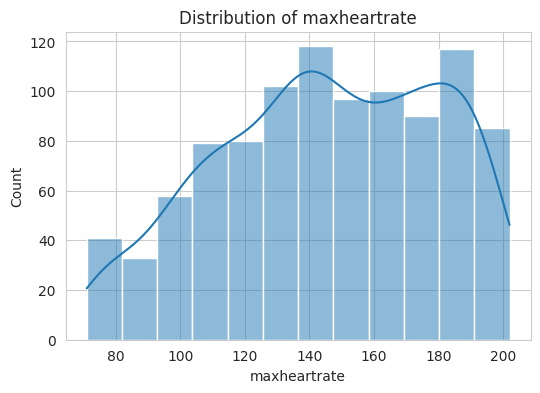

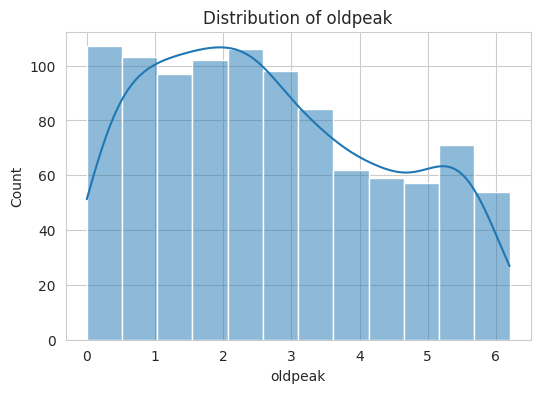

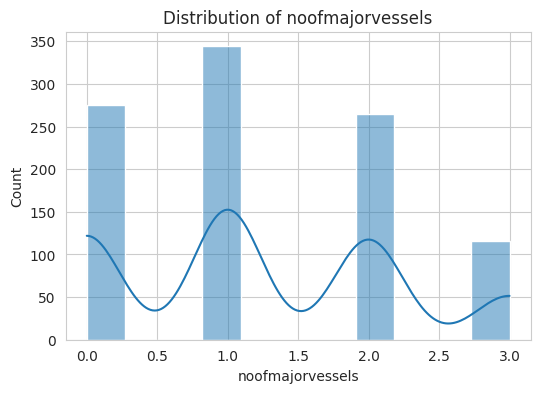

In [ ]:
# NUMERICAL FEATURES DISTRIBUTION
num_cols = [
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'oldpeak',
    'noofmajorvessels'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

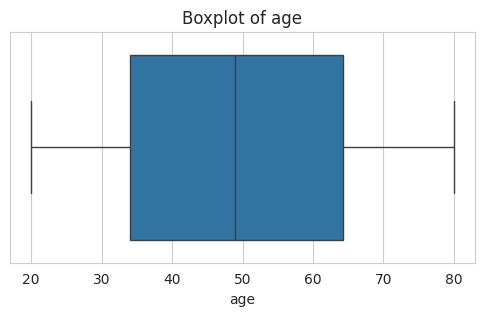

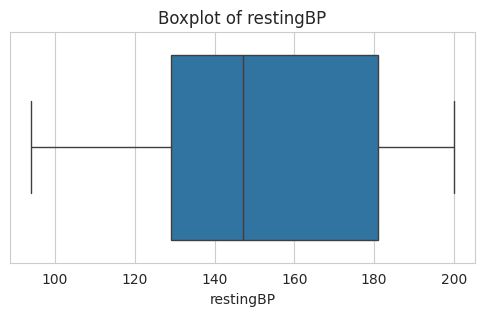

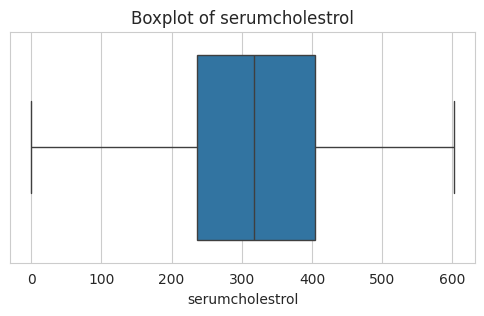

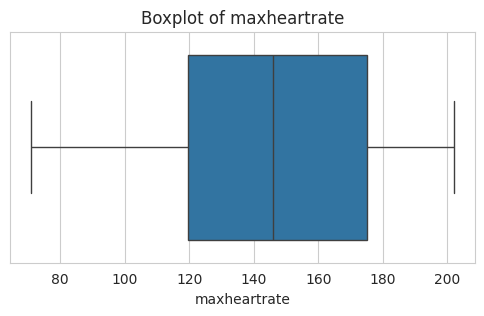

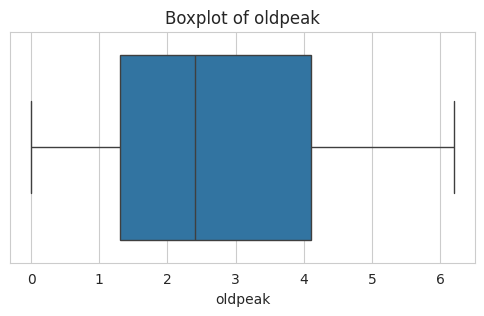

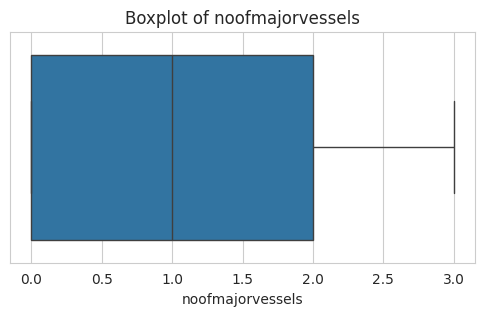

In [ ]:
# OUTLIER DETECTION

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

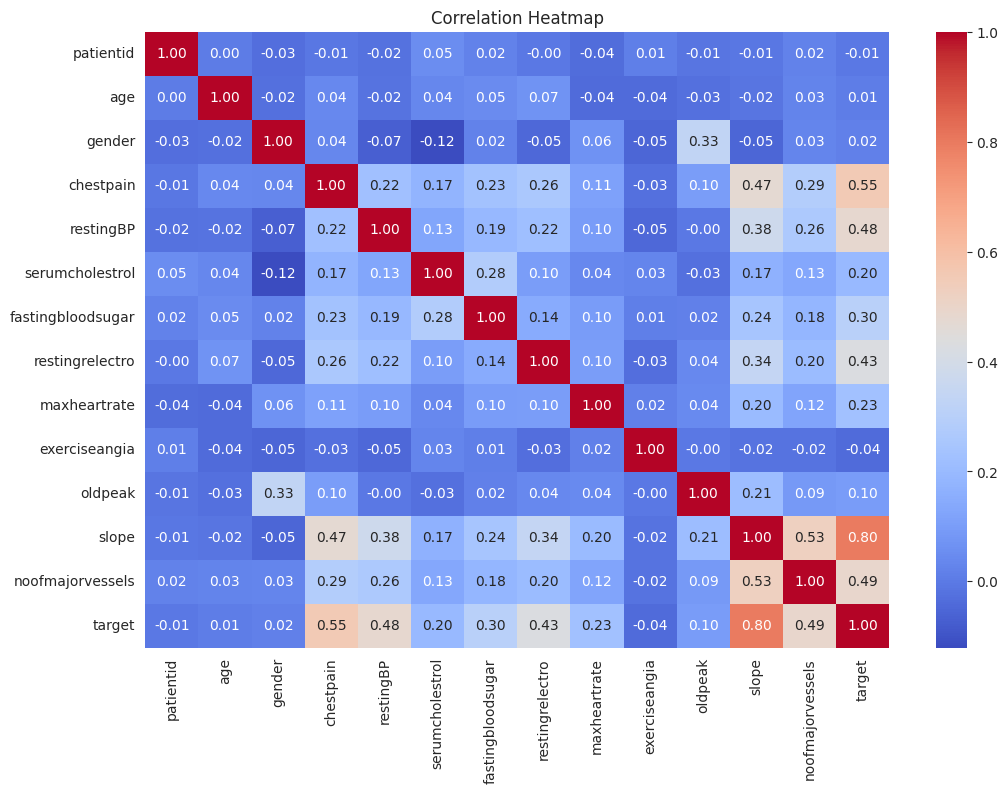

In [ ]:
# CORRELATION HEATMAP

plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

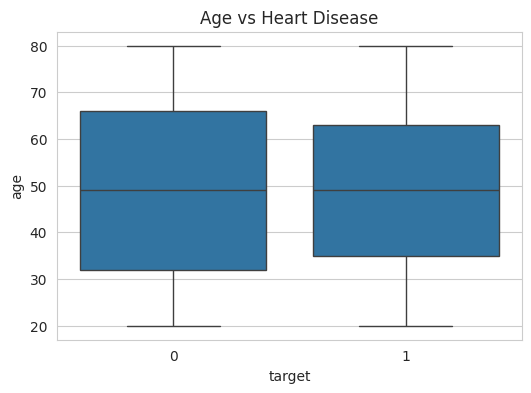

In [ ]:
# AGE VS HEART DISEASE

plt.figure(figsize=(6,4))
sns.boxplot(
    x='target',
    y='age',
    data=df
)
plt.title("Age vs Heart Disease")
plt.show()

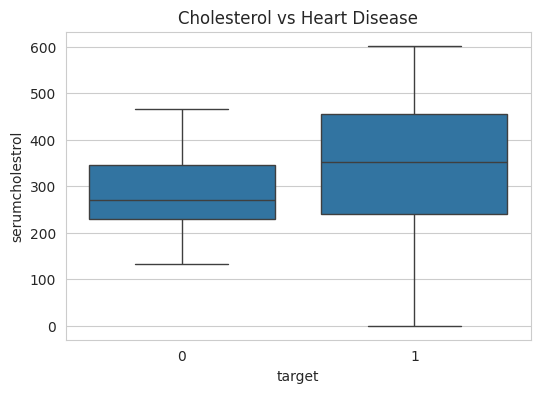

In [ ]:
# CHOLESTEROL VS HEART DISEASE

plt.figure(figsize=(6,4))
sns.boxplot(
    x='target',
    y='serumcholestrol',
    data=df
)
plt.title("Cholesterol vs Heart Disease")
plt.show()

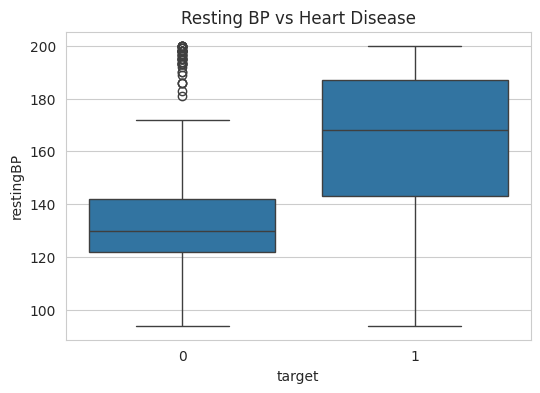

In [ ]:
# RESTING BP VS HEART DISEASE

plt.figure(figsize=(6,4))
sns.boxplot(
    x='target',
    y='restingBP',
    data=df
)
plt.title("Resting BP vs Heart Disease")
plt.show()

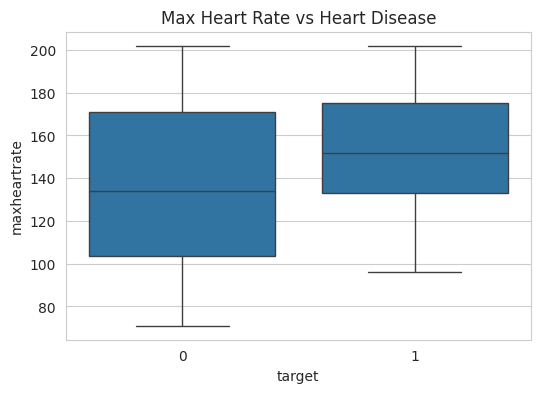

In [ ]:
# MAX HEART RATE VS HEART DISEASE

plt.figure(figsize=(6,4))
sns.boxplot(
    x='target',
    y='maxheartrate',
    data=df
)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

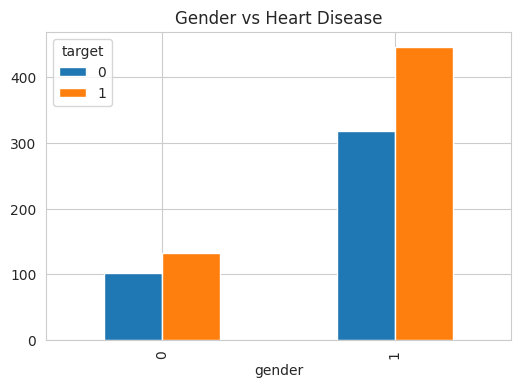

In [ ]:
# GENDER VS HEART DISEASE

pd.crosstab(
    df['gender'],
    df['target']
).plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Gender vs Heart Disease")
plt.show()

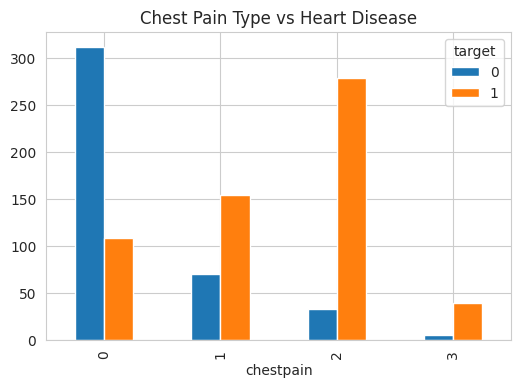

In [ ]:
# CHEST PAIN VS HEART DISEASE

pd.crosstab(
    df['chestpain'],
    df['target']
).plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Chest Pain Type vs Heart Disease")
plt.show()

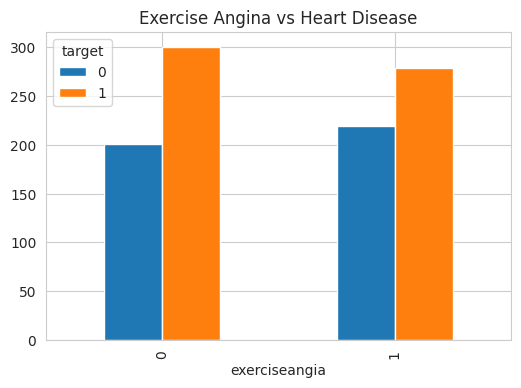

In [ ]:
# EXERCISE ANGINA VS HEART DISEASE
pd.crosstab(
    df['exerciseangia'],
    df['target']
).plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Exercise Angina vs Heart Disease")
plt.show()

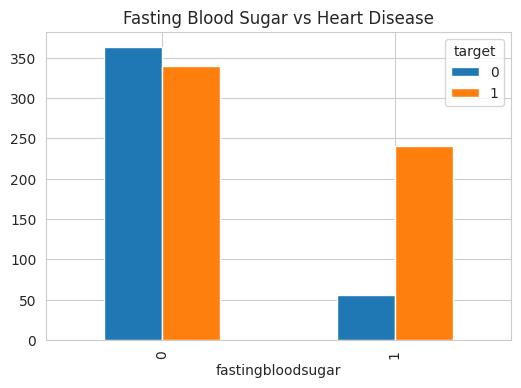

In [ ]:
# FASTING BLOOD SUGAR VS HEART DISEASE

pd.crosstab(
    df['fastingbloodsugar'],
    df['target']
).plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Fasting Blood Sugar vs Heart Disease")
plt.show()

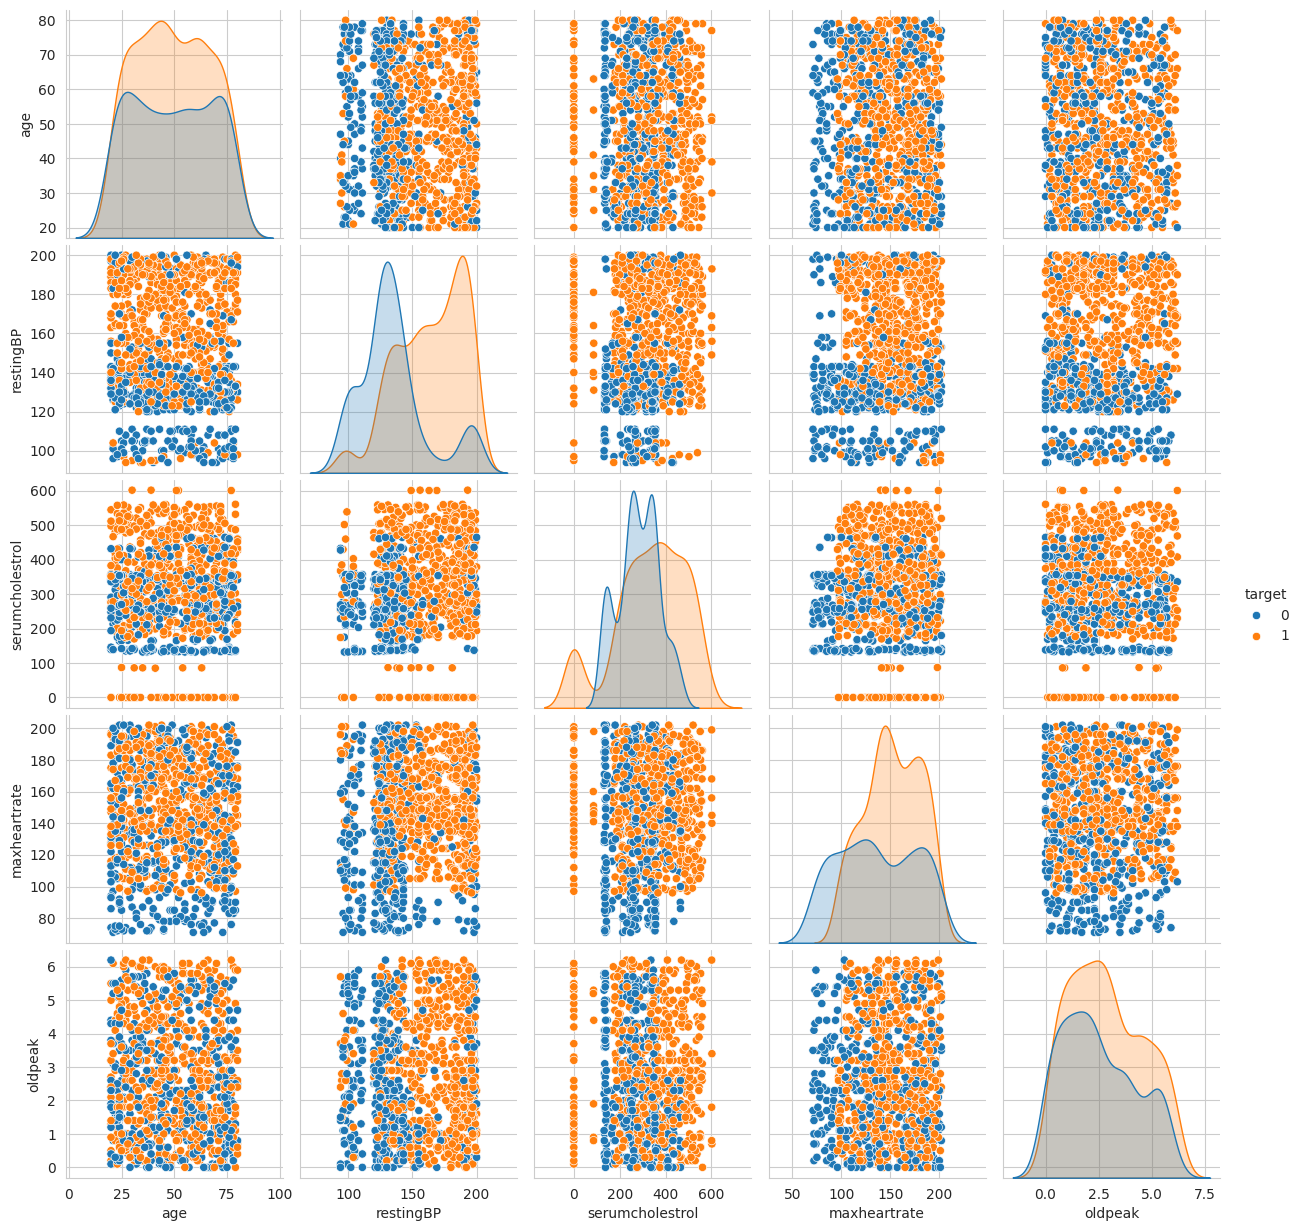

In [ ]:
# PAIRPLOT

sns.pairplot(
    df,
    vars=[
        'age',
        'restingBP',
        'serumcholestrol',
        'maxheartrate',
        'oldpeak'
    ],
    hue='target'
)

plt.show()

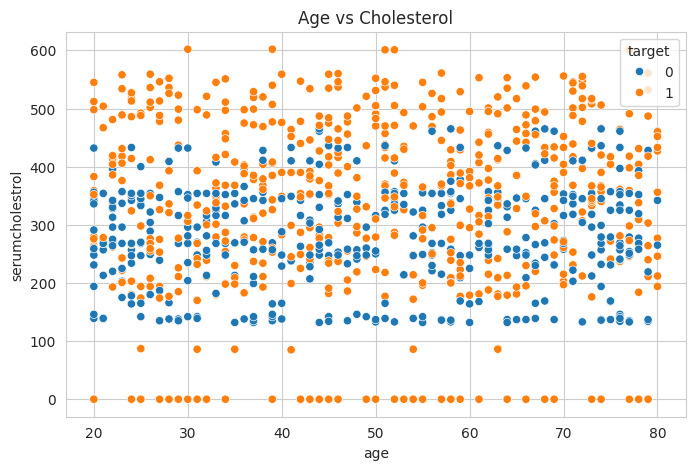

In [ ]:
# AGE VS CHOLESTEROL

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='age',
    y='serumcholestrol',
    hue='target',
    data=df
)

plt.title("Age vs Cholesterol")
plt.show()

In [ ]:
df_model = df.copy()
df_model.head()

,patientid,age,gender,chestpain,restingBP,serumcholestrol,fastingbloodsugar,restingrelectro,maxheartrate,exerciseangia,oldpeak,slope,noofmajorvessels,target
0,103368,53,1,2,171,0,0,1,147,0,5.3,3,3,1
1,119250,40,1,0,94,229,0,1,115,0,3.7,1,1,0
2,119372,49,1,2,133,142,0,0,202,1,5.0,1,0,0
3,132514,43,1,0,138,295,1,1,153,0,3.2,2,2,1
4,146211,31,1,1,199,0,0,2,136,0,5.3,3,2,1


In [ ]:
df_model.drop('patientid', axis=1, inplace=True) # Drop patient ID beacuse it is just an identifier.
df_model.columns

Index(['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol',
       'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia',
       'oldpeak', 'slope', 'noofmajorvessels', 'target'],
      dtype='object')

In [ ]:
(df_model['serumcholestrol'] == 0).sum() # Investigate Cholesterol

np.int64(53)

In [ ]:
zero_count = (df_model['serumcholestrol'] == 0).sum()

print("Count:", zero_count)

print("Percentage:",
      round((zero_count/len(df_model))*100,2),
      "%")

Count: 53
Percentage: 5.3 %


In [ ]:
#Fix Cholesterol Values
df_model['serumcholestrol'] = df_model['serumcholestrol'].replace(
    0,
    np.nan
)

df_model['serumcholestrol'].fillna(
    df_model['serumcholestrol'].median(),
    inplace=True
)

In [ ]:
(df_model['serumcholestrol'] == 0).sum()

np.int64(0)

In [ ]:
# Check Outliers
num_cols = [
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'oldpeak'
]

for col in num_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_model[
        (df_model[col] < lower) |
        (df_model[col] > upper)
    ]

    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
restingBP: 0 outliers
serumcholestrol: 0 outliers
maxheartrate: 0 outliers
oldpeak: 0 outliers


In [ ]:
# Encode Categorical Features
df_model = pd.get_dummies(
    df_model,
    columns=['chestpain', 'restingrelectro'],
    drop_first=True
)

In [ ]:
# Separate Features and Target
X = df_model.drop('target', axis=1)

y = df_model['target']

In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Feature Scaling
num_cols = [
    'age',
    'restingBP',
    'serumcholestrol',
    'maxheartrate',
    'oldpeak',
    'noofmajorvessels'
]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test_scaled[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [ ]:
print(X_train.columns)

Index(['age', 'gender', 'restingBP', 'serumcholestrol', 'fastingbloodsugar',
       'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels',
       'chestpain_1', 'chestpain_2', 'chestpain_3', 'restingrelectro_1',
       'restingrelectro_2'],
      dtype='object')


In [ ]:
X_train.to_csv("X_train.csv", index=False)
X_test.to_csv("X_test.csv", index=False)

y_train.to_csv("y_train.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

Model 1: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_lr)

precision = precision_score(y_test, y_pred_lr)

recall = recall_score(y_test, y_pred_lr)

f1 = f1_score(y_test, y_pred_lr)

roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.98
Precision: 0.9827586206896551
Recall   : 0.9827586206896551
F1 Score : 0.9827586206896551
ROC-AUC  : 0.9983579638752053


In [ ]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        84
           1       0.98      0.98      0.98       116

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



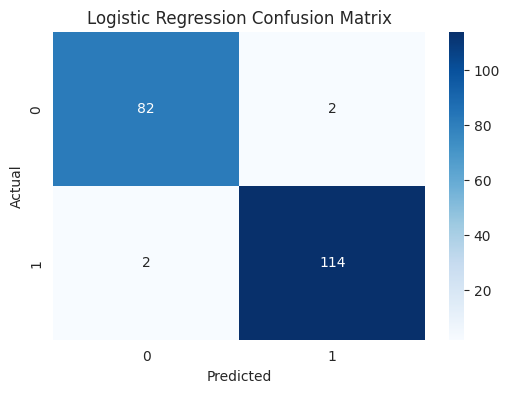

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [ ]:
# Feature Importance - This shows which features contribute most toward heart disease prediction.
coef_df = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': lr.coef_[0]
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

              Feature  Coefficient
8               slope     4.431648
1              gender     1.877594
14  restingrelectro_2     1.867176
11        chestpain_2     1.722460
12        chestpain_3     0.974541
2           restingBP     0.935145
10        chestpain_1     0.741202
4   fastingbloodsugar     0.695257
3     serumcholestrol     0.462563
5        maxheartrate     0.321271
13  restingrelectro_1     0.237117
9    noofmajorvessels     0.149697
6       exerciseangia    -0.087280
0                 age    -0.092254
7             oldpeak    -1.113296


In [ ]:
corr_target = df_model.corr()['target'].sort_values(
    ascending=False
)

print(corr_target)

target               1.000000
slope                0.797358
noofmajorvessels     0.489866
restingBP            0.482387
chestpain_2          0.428739
restingrelectro_2    0.387768
serumcholestrol      0.368809
fastingbloodsugar    0.303233
maxheartrate         0.228343
chestpain_3          0.133167
chestpain_1          0.117021
oldpeak              0.098053
restingrelectro_1    0.036168
gender               0.015769
age                  0.008356
exerciseangia       -0.039874
Name: target, dtype: float64


In [ ]:
print(df_model['slope'].value_counts())

print("\n")

print(pd.crosstab(
    df_model['slope'],
    df_model['target']
))

slope
2    322
1    299
3    199
0    180
Name: count, dtype: int64


target    0    1
slope           
0       180    0
1       228   71
2        12  310
3         0  199


Model 2: Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

y_prob_dt = dt.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_dt)

precision = precision_score(y_test, y_pred_dt)

recall = recall_score(y_test, y_pred_dt)

f1 = f1_score(y_test, y_pred_dt)

roc_auc = roc_auc_score(y_test, y_prob_dt)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.97
Precision: 0.9824561403508771
Recall   : 0.9655172413793104
F1 Score : 0.9739130434782609
ROC-AUC  : 0.9708538587848933


In [ ]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        84
           1       0.98      0.97      0.97       116

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



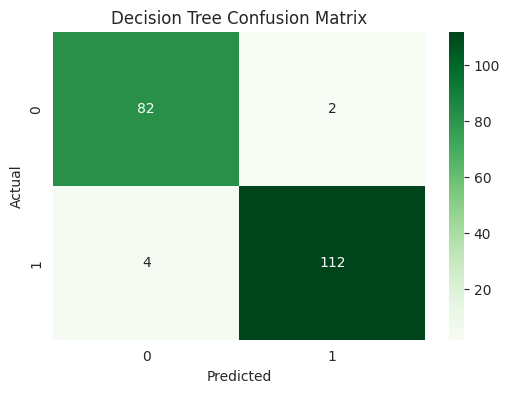

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

              Feature  Importance
8               slope    0.713559
2           restingBP    0.083613
7             oldpeak    0.055572
5        maxheartrate    0.033229
3     serumcholestrol    0.031318
1              gender    0.026401
0                 age    0.017609
11        chestpain_2    0.011730
9    noofmajorvessels    0.010811
4   fastingbloodsugar    0.009896
6       exerciseangia    0.003849
14  restingrelectro_2    0.002413
10        chestpain_1    0.000000
12        chestpain_3    0.000000
13  restingrelectro_1    0.000000


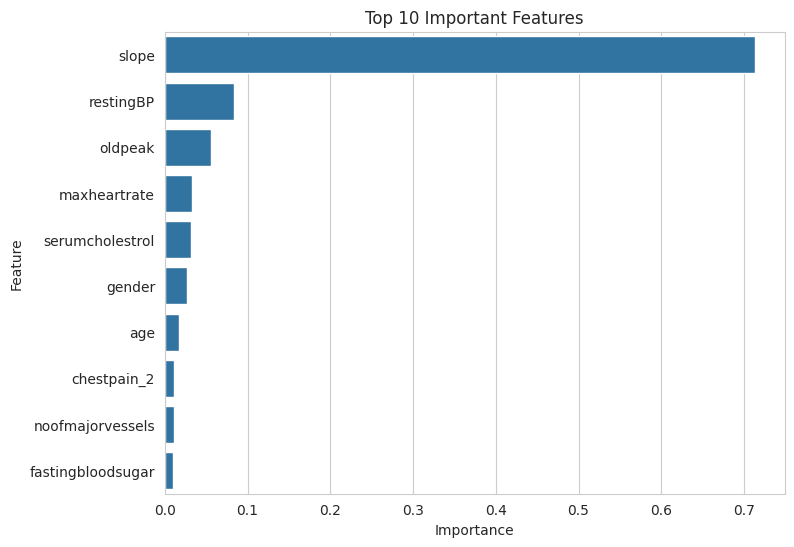

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
print("Training Accuracy:",
      dt.score(X_train, y_train))

print("Testing Accuracy:",
      dt.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.97


Model 3: Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_rf)

precision = precision_score(y_test, y_pred_rf)

recall = recall_score(y_test, y_pred_rf)

f1 = f1_score(y_test, y_pred_rf)

roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.985
Precision: 0.9829059829059829
Recall   : 0.9913793103448276
F1 Score : 0.9871244635193133
ROC-AUC  : 0.9989224137931034


In [ ]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.98      0.98        84
           1       0.98      0.99      0.99       116

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200



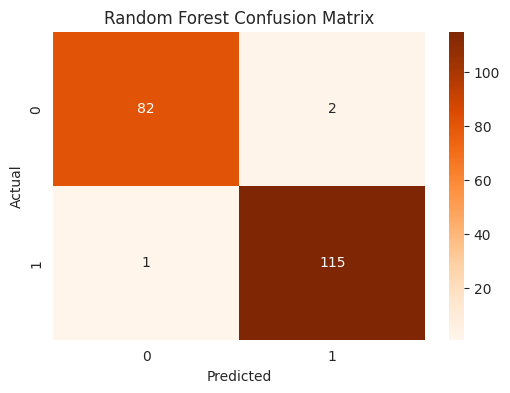

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
feature_importance_rf = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_rf)

              Feature  Importance
8               slope    0.392947
2           restingBP    0.164767
11        chestpain_2    0.079652
3     serumcholestrol    0.069128
9    noofmajorvessels    0.068990
14  restingrelectro_2    0.050764
5        maxheartrate    0.048399
7             oldpeak    0.038055
0                 age    0.024232
4   fastingbloodsugar    0.022058
1              gender    0.016511
10        chestpain_1    0.009848
13  restingrelectro_1    0.005330
12        chestpain_3    0.004957
6       exerciseangia    0.004362


In [ ]:
print("Training Accuracy:",
      rf.score(X_train, y_train))

print("Testing Accuracy:",
      rf.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.985


Model 4: KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(
    X_train_scaled,
    y_train
)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(
    X_test_scaled
)

y_prob_knn = knn.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_knn)

precision = precision_score(y_test, y_pred_knn)

recall = recall_score(y_test, y_pred_knn)

f1 = f1_score(y_test, y_pred_knn)

roc_auc = roc_auc_score(y_test, y_prob_knn)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.97
Precision: 0.9824561403508771
Recall   : 0.9655172413793104
F1 Score : 0.9739130434782609
ROC-AUC  : 0.9852729885057472


In [ ]:
print(classification_report(
    y_test,
    y_pred_knn
))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        84
           1       0.98      0.97      0.97       116

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



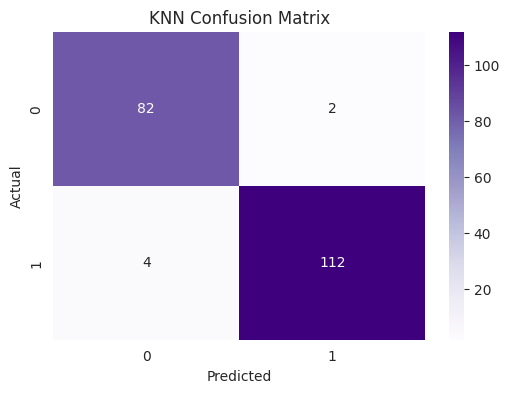

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_knn
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
train_acc = []
test_acc = []

for k in range(1,21):

    knn = KNeighborsClassifier(
        n_neighbors=k
    )

    knn.fit(
        X_train_scaled,
        y_train
    )

    train_acc.append(
        knn.score(
            X_train_scaled,
            y_train
        )
    )

    test_acc.append(
        knn.score(
            X_test_scaled,
            y_test
        )
    )

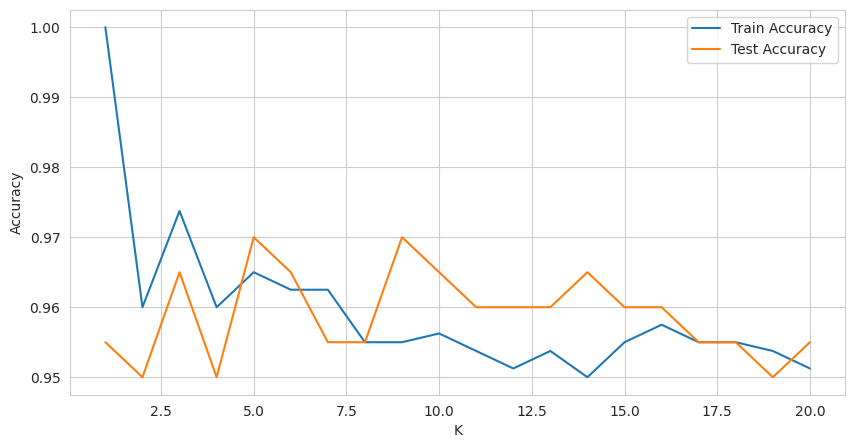

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    range(1,21),
    train_acc,
    label='Train Accuracy'
)

plt.plot(
    range(1,21),
    test_acc,
    label='Test Accuracy'
)

plt.xlabel("K")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

Model 5: SVM

In [ ]:
from sklearn.svm import SVC
svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm.fit(
    X_train_scaled,
    y_train
)

SVC(probability=True, random_state=42)

In [ ]:
y_pred_svm = svm.predict(
    X_test_scaled
)

y_prob_svm = svm.predict_proba(
    X_test_scaled
)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_svm)

precision = precision_score(y_test, y_pred_svm)

recall = recall_score(y_test, y_pred_svm)

f1 = f1_score(y_test, y_pred_svm)

roc_auc = roc_auc_score(y_test, y_prob_svm)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.975
Precision: 0.9663865546218487
Recall   : 0.9913793103448276
F1 Score : 0.9787234042553191
ROC-AUC  : 0.9989737274220032


In [ ]:
print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97        84
           1       0.97      0.99      0.98       116

    accuracy                           0.97       200
   macro avg       0.98      0.97      0.97       200
weighted avg       0.98      0.97      0.97       200



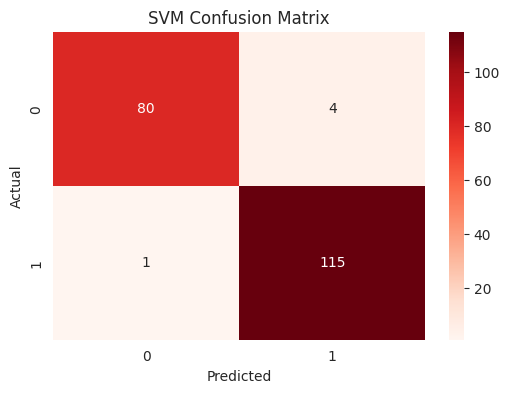

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Reds'
)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
print("Training Accuracy:",
      svm.score(X_train_scaled, y_train))

print("Testing Accuracy:",
      svm.score(X_test_scaled, y_test))

Training Accuracy: 0.98375
Testing Accuracy: 0.975


XGBoost

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [ ]:
accuracy = accuracy_score(y_test, y_pred_xgb)

precision = precision_score(y_test, y_pred_xgb)

recall = recall_score(y_test, y_pred_xgb)

f1 = f1_score(y_test, y_pred_xgb)

roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.995
Precision: 0.9914529914529915
Recall   : 1.0
F1 Score : 0.9957081545064378
ROC-AUC  : 0.999384236453202


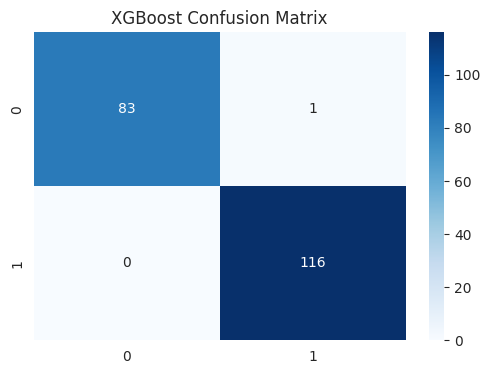

In [ ]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
feature_importance_xgb = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

feature_importance_xgb.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(feature_importance_xgb)

              Feature  Importance
8               slope    0.586341
14  restingrelectro_2    0.074759
2           restingBP    0.045640
1              gender    0.044096
11        chestpain_2    0.041019
7             oldpeak    0.039055
4   fastingbloodsugar    0.037317
3     serumcholestrol    0.027475
5        maxheartrate    0.026173
9    noofmajorvessels    0.023864
10        chestpain_1    0.019266
6       exerciseangia    0.013865
0                 age    0.012032
13  restingrelectro_1    0.009097
12        chestpain_3    0.000000


In [ ]:
#Overfitting Check
print("Training Accuracy:",
      xgb.score(X_train, y_train))

print("Testing Accuracy:",
      xgb.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.995


ANN (Artificial Neural Network)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
ann = Sequential([

    Dense(32, activation='relu',
          input_shape=(X_train_scaled.shape[1],)),

    Dropout(0.2),

    Dense(16, activation='relu'),

    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

In [ ]:
ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = ann.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - accuracy: 0.5328 - loss: 0.6437 - val_accuracy: 0.5938 - val_loss: 0.6187
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6281 - loss: 0.5936 - val_accuracy: 0.6750 - val_loss: 0.5680
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6687 - loss: 0.5493 - val_accuracy: 0.7937 - val_loss: 0.5254
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7547 - loss: 0.5030 - val_accuracy: 0.8375 - val_loss: 0.4813
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8156 - loss: 0.4613 - val_accuracy: 0.8687 - val_loss: 0.4368
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.8547 - loss: 0.4167 - val_accuracy: 0.8687 - val_loss: 0.3919
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8656 - loss: 0.3664 - val_accuracy: 0.8938 - val_loss: 0.3458
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8781 - loss: 0.3331 - val_accuracy: 0.

In [ ]:
loss, accuracy = ann.evaluate(
    X_test_scaled,
    y_test,
    verbose=0
)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9800000190734863


In [ ]:
y_prob_ann = ann.predict(
    X_test_scaled
)

y_pred_ann = (
    y_prob_ann > 0.5
).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


In [ ]:
print("Accuracy:",
      accuracy_score(y_test,
                     y_pred_ann))

print("Precision:",
      precision_score(y_test,
                      y_pred_ann))

print("Recall:",
      recall_score(y_test,
                   y_pred_ann))

print("F1:",
      f1_score(y_test,
               y_pred_ann))

print("ROC-AUC:",
      roc_auc_score(y_test,
                    y_prob_ann))

Accuracy: 0.98
Precision: 0.9827586206896551
Recall: 0.9827586206896551
F1: 0.9827586206896551
ROC-AUC: 0.9984605911330049


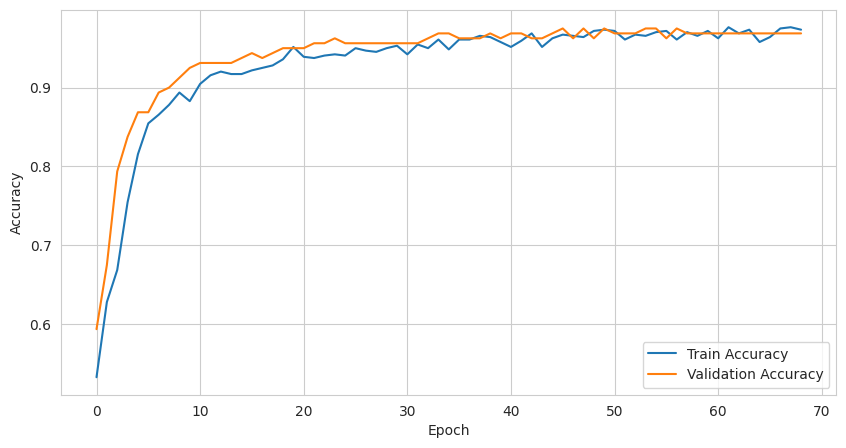

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
comparison_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'KNN',
        'SVM',
        'XGBoost',
        'ANN'
    ],

    'Accuracy': [
        0.980,
        0.970,
        0.985,
        0.970,
        0.975,
        0.995,
        0.995
    ],

    'Precision': [
        0.9828,
        0.9825,
        0.9829,
        0.9825,
        0.9664,
        0.9915,
        0.9915
    ],

    'Recall': [
        0.9828,
        0.9655,
        0.9914,
        0.9655,
        0.9914,
        1.0000,
        1.0000
    ],

    'F1 Score': [
        0.9828,
        0.9739,
        0.9871,
        0.9739,
        0.9787,
        0.9957,
        0.9957
    ],

    'ROC-AUC': [
        0.9984,
        0.9709,
        0.9989,
        0.9853,
        0.9990,
        0.9994,
        0.9992
    ]
})

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

comparison_df.reset_index(drop=True, inplace=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,ANN,0.995,0.9915,1.0000,0.9957,0.9992
1,XGBoost,0.995,0.9915,1.0000,0.9957,0.9994
2,Random Forest,0.985,0.9829,0.9914,0.9871,0.9989
3,Logistic Regression,0.980,0.9828,0.9828,0.9828,0.9984
4,SVM,0.975,0.9664,0.9914,0.9787,0.9990
5,Decision Tree,0.970,0.9825,0.9655,0.9739,0.9709
6,KNN,0.970,0.9825,0.9655,0.9739,0.9853


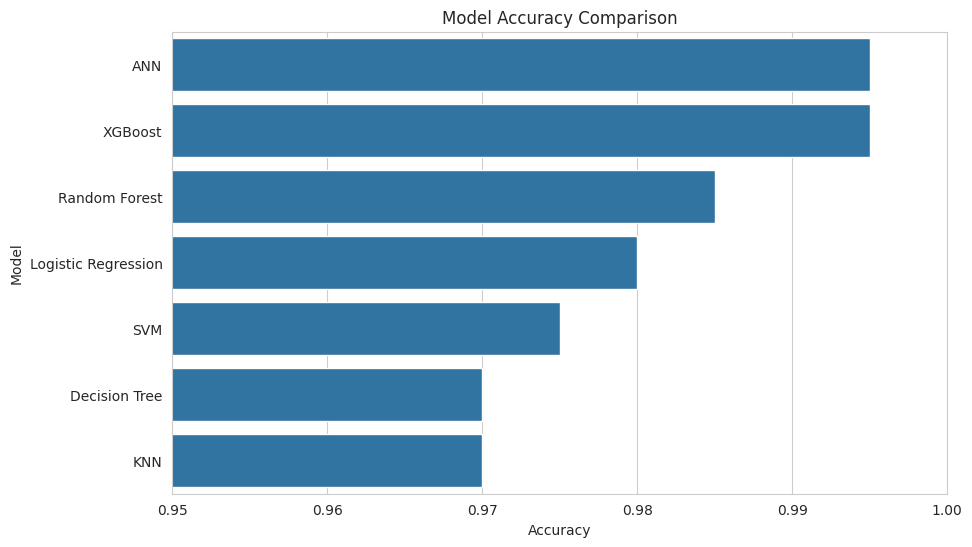

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x='Accuracy',
    y='Model'
)

plt.title('Model Accuracy Comparison')
plt.xlim(0.95, 1.0)

plt.show()

In [ ]:
import joblib

joblib.dump(xgb, 'heart_disease_xgboost_model.pkl')

print("Model saved successfully!")

Model saved successfully!


EXPLAINABLE AI (XAI) – SHAP Analysis

In [ ]:
!pip install shap -q
import shap


In [ ]:
# Initialize JS visualization if you are running this in a Jupyter/Colab environment
shap.initjs()

# 1. INITIALIZE THE EXPLAINER
# XGBoost is a tree-based model, so we use SHAP's optimized TreeExplainer
explainer = shap.TreeExplainer(xgb)

# Calculate SHAP values for the test dataset
shap_values = explainer(X_test)

Global Explanations

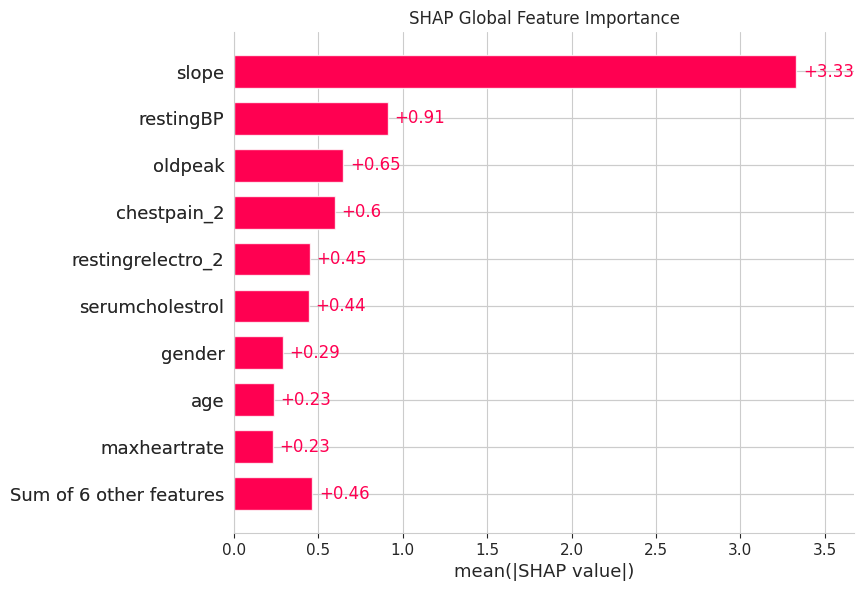

In [ ]:
# 2. GLOBAL FEATURE IMPORTANCE (BAR PLOT)
# Shows the average absolute impact of each feature on the model's output
plt.figure(figsize=(8, 6))
plt.title("SHAP Global Feature Importance")
shap.plots.bar(shap_values)
plt.show()

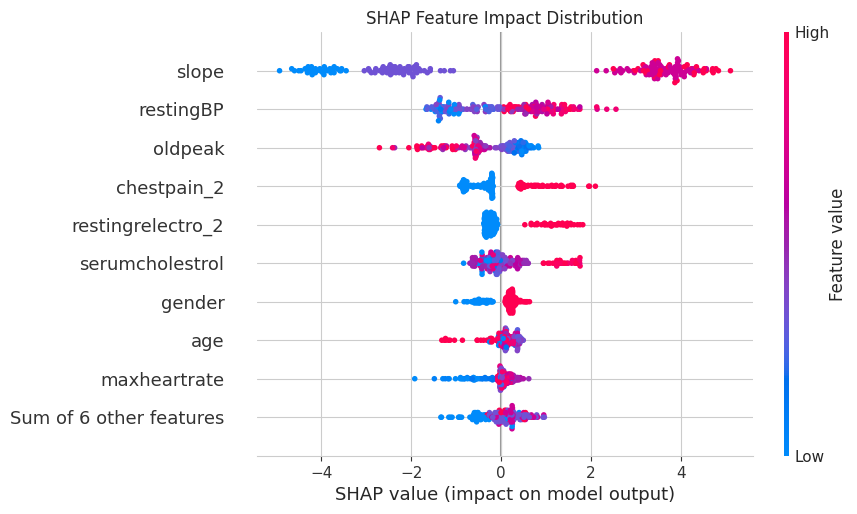

In [ ]:
# 3. GLOBAL DIRECTIONAL IMPACT (BEESWARM PLOT)
# Shows how high or low values of a feature impact the prediction.
# Red = High value of that feature, Blue = Low value of that feature
plt.figure(figsize=(8, 6))
plt.title("SHAP Feature Impact Distribution")
shap.plots.beeswarm(shap_values)
plt.show()

LOCAL EXPLANATION (WATERFALL PLOT)


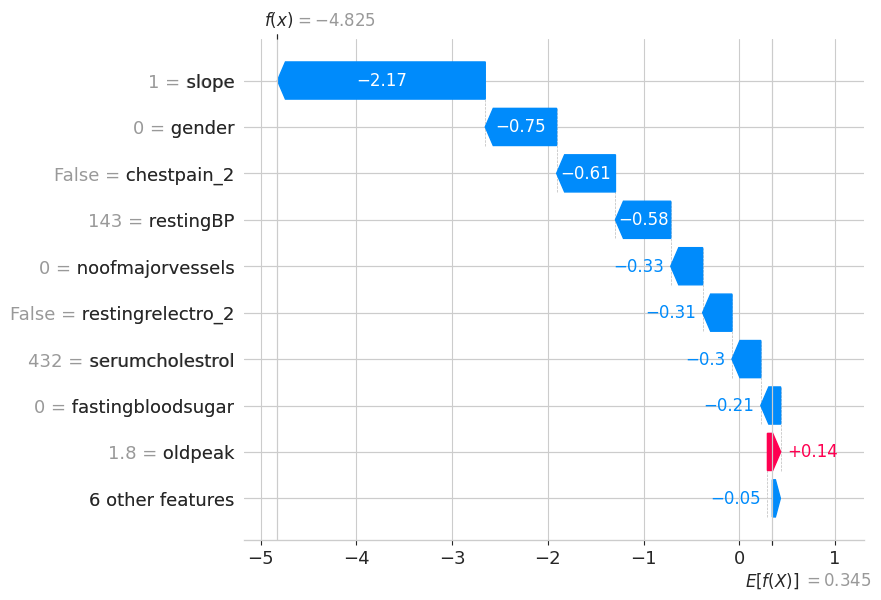

In [ ]:
# 4. LOCAL EXPLANATION (WATERFALL PLOT)
# Let's explain the prediction for the very first patient in the test set (Index 0)
# This shows how we start from the 'base value' (average prediction) and how each
# feature pushes the prediction higher (red) or lower (blue) for this specific patient.

plt.figure(figsize=(8, 6))
shap.plots.waterfall(shap_values[0])
plt.show()

Feature Interaction


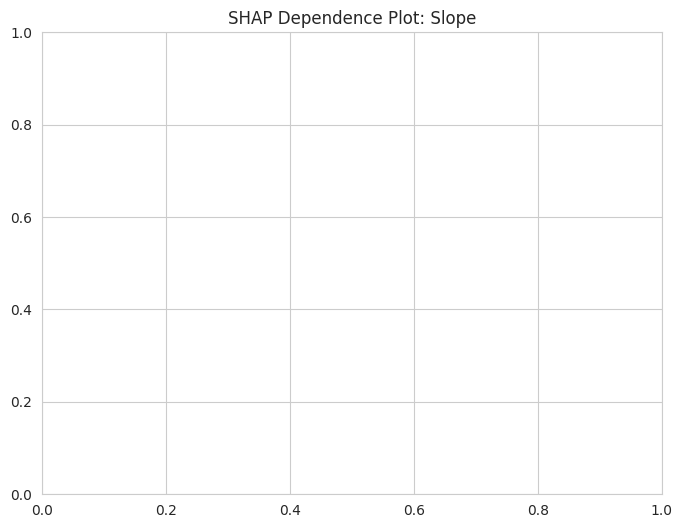

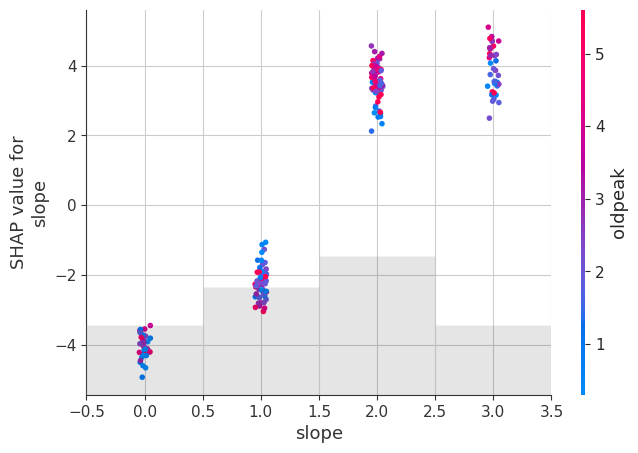

In [ ]:
# 5. DEPENDENCE PLOT
# Since 'slope' was identified as a highly important feature in your XGBoost analysis,
# let's visualize its exact relationship with the prediction output.
plt.figure(figsize=(8, 6))
plt.title("SHAP Dependence Plot: Slope")
shap.plots.scatter(shap_values[:, "slope"], color=shap_values)
plt.show()

In [ ]:
print("\nExplainable AI analysis complete!")


Explainable AI analysis complete!
